# Exercise 2

## Imports

In [127]:
import autograd.numpy as np
from autograd import grad
import copy


## Load dataset

In [128]:
csvname = 'multiple_sine_waves.csv'
data = np.loadtxt(csvname,delimiter=',')
x = data[:2,:]
y = data[2:,:]

## Define feature transformation and model

In [129]:
def feature_transforms(x,w):
    a = w[0] + np.dot(x.T,w[1:])
    return np.sin(a).T

def model(x,w):    
    # feature transformation 
    f = feature_transforms(x,w[0])
    
    # compute linear combination and return
    a = w[1][0] + np.dot(f.T,w[1][1:])
    return a.T


## Least squre cost

In [130]:
def least_square_cost(w,x,y):
    a = model(x,w)
    return np.sum((a-y)**2)

## Gradient descent

In [131]:
# gradient descent function - inputs: g (input function), 
# alpha (steplength parameter), 
# max_its (maximum number of iterations), w (initialization)
def gradient_descent(g,alpha,max_its,w):
    # compute gradient module using autograd
    gradient = grad(g)

    # run the gradient descent loop
    weight_history = [w]     # container for weight history
    cost_history = [g(w)]    # container for corresponding cost function history
    for k in range(max_its):
        # evaluate the gradient, store current weights and cost function value
        grad_eval = gradient(w)

        # take gradient descent step
        w = [w[i] - alpha * grad_eval[i] for i in range(len(w))]

        # record weight and cost
        weight_history.append(w)
        cost_history.append(g(w))
    return weight_history,cost_history

## Run model

In [132]:
max_its = 2000
alpha = 10**(-3)
w = [np.random.randn(3, 2), np.random.randn(3)]

g = lambda w: least_square_cost(w, x, y)

weight_history, cost_history = gradient_descent(g, alpha, max_its, w.copy())

## Extract optimal parameters

In [133]:
optimal_feature_param = weight_history[-1][0]
optimal_putput_param = weight_history[-1][1]

print("Optimal feature parameters:")
print(optimal_feature_param)

print("\nOptimal output layer parameters:")
print(optimal_putput_param)


Optimal feature parameters:
[[ 0.27261085  0.37679253]
 [ 0.34117547 -0.3514302 ]
 [-0.08310565 -0.24482455]]

Optimal output layer parameters:
[-0.0041938  -0.25438531  0.58986611]


## Plot the results

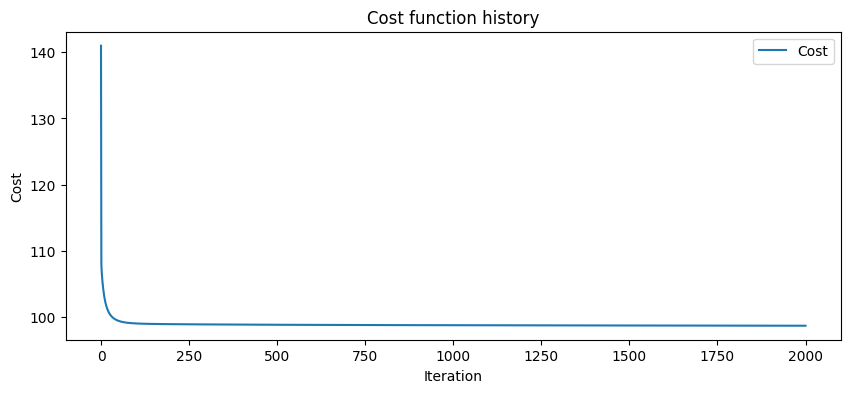

In [134]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
plt.plot(cost_history, label="Cost")
plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.legend()
plt.title("Cost function history")
plt.show()
